In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/processed/paimana_features.csv",
    encoding="utf-8-sig"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1981
Columns: 30


In [2]:
important_columns = [
    "original_cost_cr",
    "revised_cost_cr",
    "cumulative_expenditure_cr",
    "physical_progress_pct",
    "cost_overrun_pct",
    "expenditure_ratio_pct",
    "expenditure_progress_gap",
    "planned_duration_days",
    "schedule_delay_days",
    "schedule_delay_months"
]

df[important_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
original_cost_cr,1981.0,1874.135290,4960.200777,102.400000,355.790000,790.780000,1511.570000,108000.000000
revised_cost_cr,1981.0,2159.718511,7236.919493,0.100000,358.190000,786.910000,1656.730000,188000.000000
cumulative_expenditure_cr,1981.0,1027.818016,4701.135060,0.000000,35.570000,226.460000,663.380000,124623.000000
physical_progress_pct,1981.0,60.209621,34.764130,0.000000,28.600000,70.000000,93.100000,100.000000
cost_overrun_pct,1981.0,8.669047,50.448229,-99.958099,0.000000,0.000000,1.329356,1231.528018
expenditure_ratio_pct,1981.0,45.096748,56.911622,0.000000,5.747418,35.938209,65.858467,911.649527
expenditure_progress_gap,1981.0,-15.112874,53.186280,-100.000000,-38.043358,-13.854120,0.000000,856.649527
planned_duration_days,1981.0,1316.562847,1301.923496,-425.000000,730.000000,731.000000,1430.000000,14824.000000
schedule_delay_days,1627.0,705.791026,959.463499,-10837.000000,90.000000,427.000000,943.000000,9131.000000
schedule_delay_months,1627.0,23.186302,31.519826,-356.011827,2.956636,14.027595,30.978975,299.967148


In [3]:
missing = df[important_columns].isnull().sum()

print("Missing values:")
print(missing)

Missing values:
original_cost_cr               0
revised_cost_cr                0
cumulative_expenditure_cr      0
physical_progress_pct          0
cost_overrun_pct               0
expenditure_ratio_pct          0
expenditure_progress_gap       0
planned_duration_days          0
schedule_delay_days          354
schedule_delay_months        354
dtype: int64


In [4]:
df["has_cost_overrun"] = np.where(
    df["cost_overrun_pct"] > 0,
    1,
    0
)

df["has_schedule_delay"] = np.where(
    df["schedule_delay_days"] > 0,
    1,
    0
)

print("Cost Overrun Projects:")
print(df["has_cost_overrun"].value_counts())

print("\nSchedule Delay Projects:")
print(df["has_schedule_delay"].value_counts())

Cost Overrun Projects:
has_cost_overrun
0    1439
1     542
Name: count, dtype: int64

Schedule Delay Projects:
has_schedule_delay
1    1245
0     736
Name: count, dtype: int64


In [5]:
def cost_overrun_category(value):

    if pd.isna(value):
        return "Unknown"

    elif value <= 0:
        return "No Overrun"

    elif value <= 10:
        return "Low"

    elif value <= 25:
        return "Moderate"

    else:
        return "High"


df["cost_overrun_category"] = df["cost_overrun_pct"].apply(
    cost_overrun_category
)

print(
    df["cost_overrun_category"].value_counts()
)

cost_overrun_category
No Overrun    1439
High           242
Low            176
Moderate       124
Name: count, dtype: int64


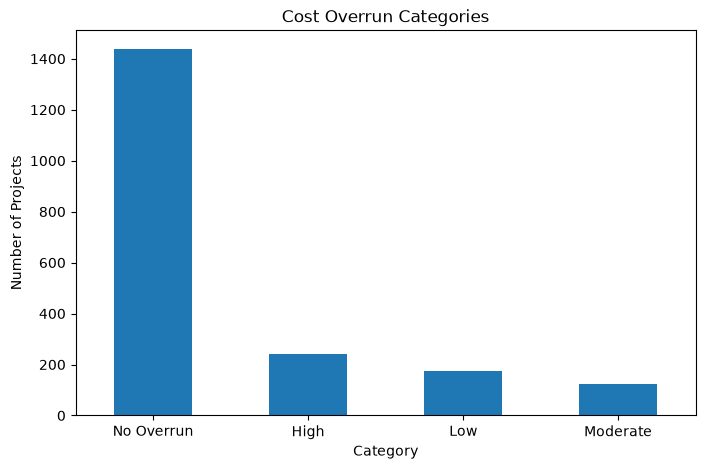

In [6]:
plt.figure(figsize=(8, 5))

df["cost_overrun_category"].value_counts().plot(
    kind="bar"
)

plt.title("Cost Overrun Categories")
plt.xlabel("Category")
plt.ylabel("Number of Projects")
plt.xticks(rotation=0)

plt.show()

In [7]:
def delay_category(value):

    if pd.isna(value):
        return "Unknown"

    elif value <= 0:
        return "No Delay"

    elif value <= 180:
        return "Short Delay"

    elif value <= 365:
        return "Moderate Delay"

    else:
        return "Long Delay"


df["delay_category"] = df["schedule_delay_days"].apply(
    delay_category
)

print(
    df["delay_category"].value_counts()
)

delay_category
Long Delay        884
No Delay          382
Unknown           354
Moderate Delay    265
Short Delay        96
Name: count, dtype: int64


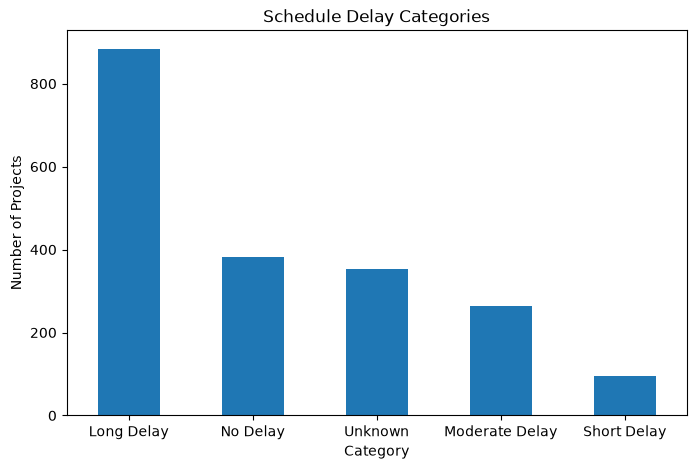

In [8]:
plt.figure(figsize=(8, 5))

df["delay_category"].value_counts().plot(
    kind="bar"
)

plt.title("Schedule Delay Categories")
plt.xlabel("Category")
plt.ylabel("Number of Projects")
plt.xticks(rotation=0)

plt.show()

In [9]:
correlation_columns = [
    "original_cost_cr",
    "revised_cost_cr",
    "cumulative_expenditure_cr",
    "physical_progress_pct",
    "cost_overrun_pct",
    "expenditure_ratio_pct",
    "expenditure_progress_gap",
    "planned_duration_days",
    "schedule_delay_days"
]

correlation_matrix = df[correlation_columns].corr()

print(correlation_matrix)

                           original_cost_cr  revised_cost_cr  \
original_cost_cr                   1.000000         0.886692   
revised_cost_cr                    0.886692         1.000000   
cumulative_expenditure_cr          0.763861         0.835569   
physical_progress_pct             -0.034999         0.005968   
cost_overrun_pct                   0.049224         0.169202   
expenditure_ratio_pct              0.064733         0.134047   
expenditure_progress_gap           0.092143         0.139535   
planned_duration_days              0.182267         0.192621   
schedule_delay_days                0.068036         0.088804   

                           cumulative_expenditure_cr  physical_progress_pct  \
original_cost_cr                            0.763861              -0.034999   
revised_cost_cr                             0.835569               0.005968   
cumulative_expenditure_cr                   1.000000               0.117600   
physical_progress_pct                      

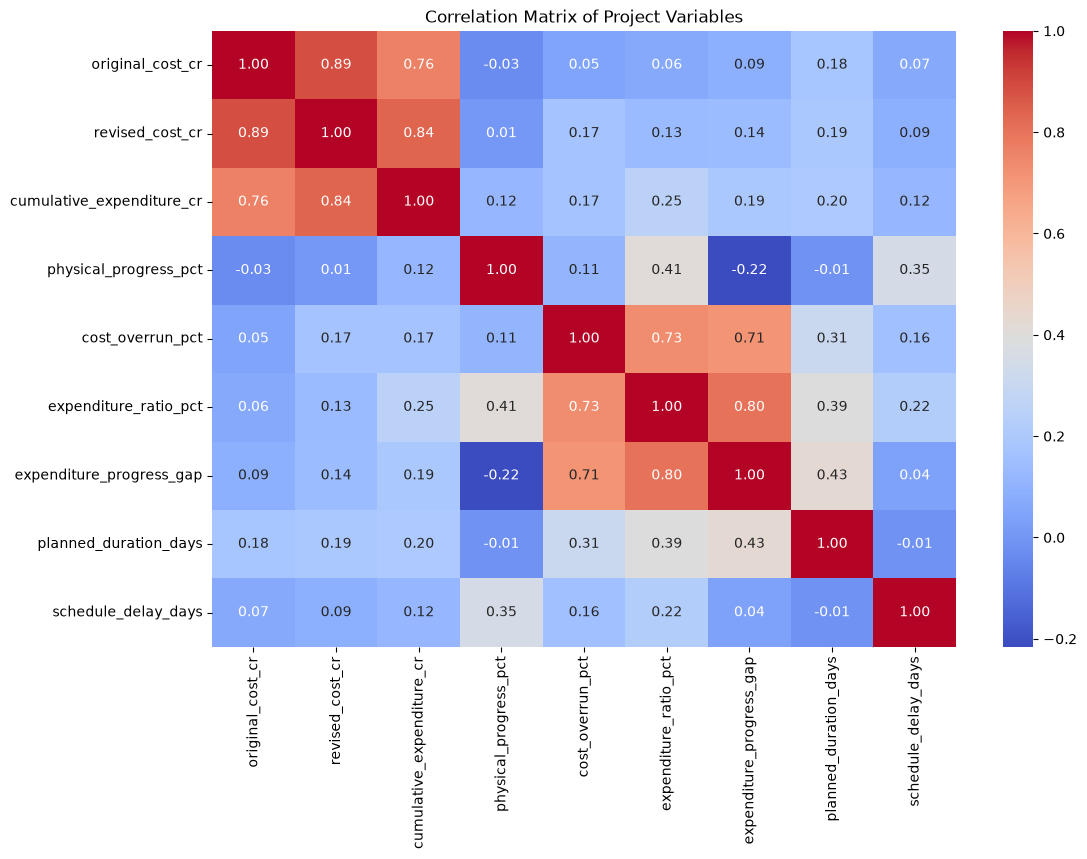

In [10]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Project Variables")

plt.show()

In [11]:
size_analysis = (
    df.groupby("project_size_category")["cost_overrun_pct"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

print(size_analysis)

                       count       mean  median
project_size_category                          
Mega                      61  20.662420     0.0
Large                    690  10.403035     0.0
Very Large                61  10.076594     0.0
Small                    716   7.985401     0.0
Medium                   453   5.303888     0.0


In [12]:
sector_analysis = (
    df.groupby("sector")["cost_overrun_pct"]
    .agg(["count", "mean", "median"])
)

sector_analysis = sector_analysis[
    sector_analysis["count"] >= 10
]

sector_analysis = sector_analysis.sort_values(
    "mean",
    ascending=False
)

print(sector_analysis)

                                    count        mean     median
sector                                                          
Water Resources                        40  110.327480  56.151198
Healthcare                             34   35.002205   0.000000
Electricity Generation                 40   34.734297   0.000000
Railways                              262   24.379465   0.000000
Energy Storage                         16   17.545299   0.000000
Telecommunication                      12   12.260337   0.000000
Steel                                  18    8.675208   0.000000
Oil & Gas                              96    7.812056   0.000000
Urban Public Transport                 27    4.572045   0.000000
Aviation & Aviation Infrastructure     26    3.822314   0.000000
Real Estate                            11    3.311232   0.000000
Transmission & Distribution            69    1.784042   0.000000
Waste & Water                          27    1.718531   0.000000
Roads & Highways         

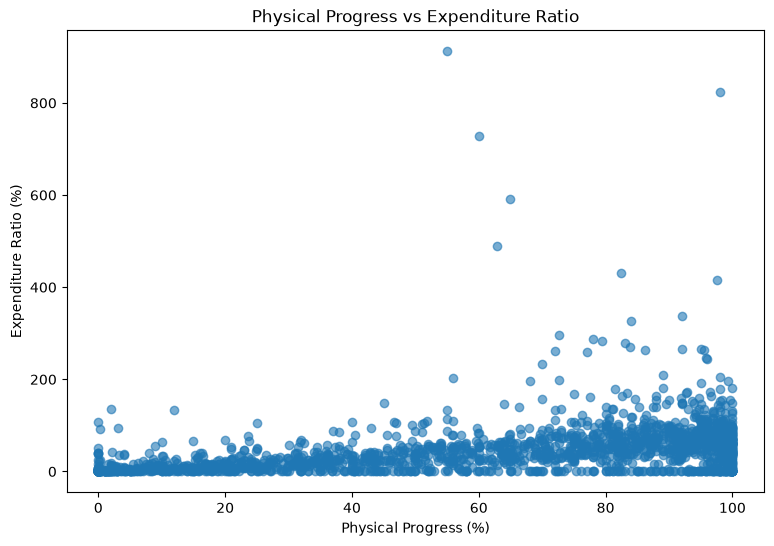

In [13]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["physical_progress_pct"],
    df["expenditure_ratio_pct"],
    alpha=0.6
)

plt.xlabel("Physical Progress (%)")
plt.ylabel("Expenditure Ratio (%)")
plt.title("Physical Progress vs Expenditure Ratio")

plt.show()

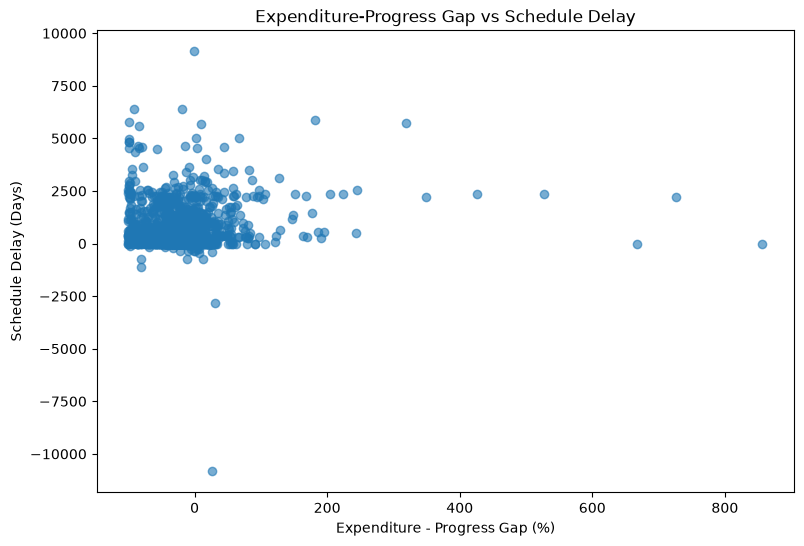

In [14]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["expenditure_progress_gap"],
    df["schedule_delay_days"],
    alpha=0.6
)

plt.xlabel("Expenditure - Progress Gap (%)")
plt.ylabel("Schedule Delay (Days)")
plt.title(
    "Expenditure-Progress Gap vs Schedule Delay"
)

plt.show()

In [15]:
warning_projects = df[
    (df["expenditure_progress_gap"] > 20) |
    (df["cost_overrun_pct"] > 10) |
    (df["schedule_delay_days"] > 180)
]

print(
    "Potential Warning Projects:",
    len(warning_projects)
)

warning_projects[
    [
        "project_name",
        "sector",
        "original_cost_cr",
        "cost_overrun_pct",
        "physical_progress_pct",
        "expenditure_progress_gap",
        "schedule_delay_days"
    ]
].head(20)

Potential Warning Projects: 1251


,project_name,sector,original_cost_cr,cost_overrun_pct,physical_progress_pct,expenditure_progress_gap,schedule_delay_days
0,Construction of New Domestic Terminal Building...,Aviation & Aviation Infrastructure,265.91,0.000000,65.00,-16.461021,181.0
1,Construction of New Integrated Terminal Buildi...,Aviation & Aviation Infrastructure,611.80,0.000000,87.20,-1.691664,1491.0
2,Construction of New Domestic Terminal Building...,Aviation & Aviation Infrastructure,347.15,0.000000,90.00,-40.802247,304.0
3,Guwahati Airport New Integrated Terminal Build...,Aviation & Aviation Infrastructure,1712.00,47.196262,98.00,55.469042,457.0
7,Goa Airport Terminal Building Extension Project,Aviation & Aviation Infrastructure,255.69,0.000000,100.00,-38.714850,1582.0
9,Development of Dholera International Greenfiel...,Aviation & Aviation Infrastructure,1305.00,18.850575,82.00,-13.278161,0.0
13,Development of additional RESA on either end o...,Aviation & Aviation Infrastructure,484.57,0.000000,59.00,-16.776998,456.0
14,Construction of Terminal Building & Associated...,Aviation & Aviation Infrastructure,480.00,33.333333,78.90,25.643750,1764.0
15,C/o NITB Imphal Airport,Aviation & Aviation Infrastructure,499.00,0.000000,50.69,-10.211042,883.0
16,SITC of ATM Automation System and ASMGCS [Incl...,Aviation & Aviation Infrastructure,500.48,0.000000,78.00,-1.833120,334.0


In [16]:
df.to_csv(
    "../data/processed/paimana_phase3_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Phase 3 analysis dataset saved successfully!")

Phase 3 analysis dataset saved successfully!
